# 📈 Univariate Linear Regression

In this session, we will:
1. Load housing data (California or Ontario).
2. Select a single feature for univariate regression.
3. Implement Linear Regression **from scratch** using Gradient Descent.
4. Implement Linear Regression using `scikit-learn`.
5. Compare results and visualize the fit.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Load California Data
df = pd.read_csv('../data/raw/california_housing.csv')
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## 1. Problem Definition & Preprocessing

We will predict **MedHouseVal** (Median House Value) using **MedInc** (Median Income).
Univariate Hypothesis: $h_\theta(x) = \theta_0 + \theta_1 x$

In [2]:
# Feature Selection
X = df[['MedInc']].values
y = df['MedHouseVal'].values

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling (Crucial for Gradient Descent)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 2. Implementation from Scratch (Gradient Descent)

In [3]:
class LinearRegressionScratch:
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.lr = learning_rate
        self.n_iter = n_iterations
        self.weights = None
        self.bias = None
        self.cost_history = []

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        for _ in range(self.n_iter):
            y_predicted = np.dot(X, self.weights) + self.bias
            
            # Gradient computation
            dw = (1 / n_samples) * np.dot(X.T, (y_predicted - y))
            db = (1 / n_samples) * np.sum(y_predicted - y)

            # Update parameters
            self.weights -= self.lr * dw
            self.bias -= self.lr * db
            
            # Cost (MSE)
            cost = (1 / (2 * n_samples)) * np.sum((y_predicted - y) ** 2)
            self.cost_history.append(cost)

    def predict(self, X):
        return np.dot(X, self.weights) + self.bias

# Train Scratch Model
model_scratch = LinearRegressionScratch(learning_rate=0.1, n_iterations=1000)
model_scratch.fit(X_train_scaled, y_train)

y_pred_scratch = model_scratch.predict(X_test_scaled)

rmse_scratch = np.sqrt(mean_squared_error(y_test, y_pred_scratch))
print(f"Scratch Model RMSE: {rmse_scratch:.4f}")

Scratch Model RMSE: 0.8421


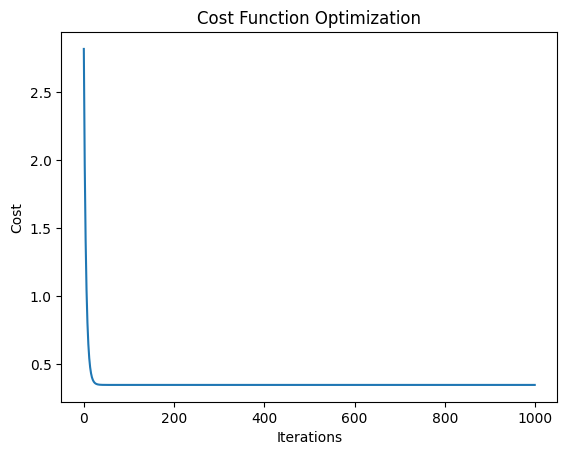

In [4]:
# Plot Cost History
plt.plot(model_scratch.cost_history)
plt.title('Cost Function Optimization')
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.show()

## 3. Scikit-Learn Implementation

In [5]:
model_sklearn = LinearRegression()
model_sklearn.fit(X_train_scaled, y_train)
y_pred_sklearn = model_sklearn.predict(X_test_scaled)

rmse_sklearn = np.sqrt(mean_squared_error(y_test, y_pred_sklearn))
print(f"Sklearn Model RMSE: {rmse_sklearn:.4f}")

Sklearn Model RMSE: 0.8421


## 4. Visualization & Comparison

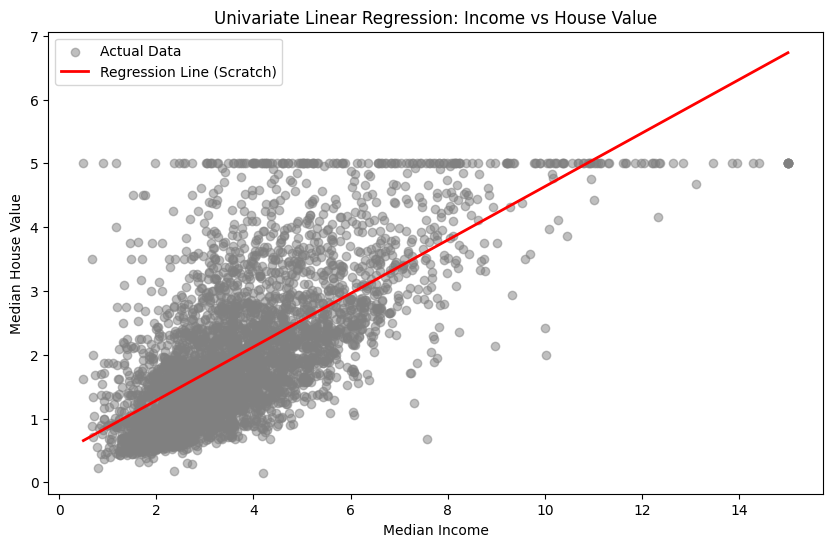

In [6]:
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='gray', alpha=0.5, label='Actual Data')

# We need to plot the line using the original scale
X_range = np.linspace(X_test.min(), X_test.max(), 100).reshape(-1, 1)
X_range_scaled = scaler.transform(X_range)

y_range_pred = model_scratch.predict(X_range_scaled)

plt.plot(X_range, y_range_pred, color='red', linewidth=2, label='Regression Line (Scratch)')
plt.title('Univariate Linear Regression: Income vs House Value')
plt.xlabel('Median Income')
plt.ylabel('Median House Value')
plt.legend()
plt.show()

In [7]:
print("Comparison:")
print(f"Weights (Scratch): {model_scratch.weights[0]:.4f}, Bias: {model_scratch.bias:.4f}")
print(f"Weights (Sklearn): {model_sklearn.coef_[0]:.4f}, Bias: {model_sklearn.intercept_:.4f}")

Comparison:
Weights (Scratch): 0.7985, Bias: 2.0719
Weights (Sklearn): 0.7985, Bias: 2.0719
